In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import warnings
warnings.filterwarnings('ignore')

In [2]:
def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None):
    """A residual block."""
    if conv_shortcut:
        shortcut = layers.Conv2D(4 * filters, 1, strides=stride, name=name + '_0_conv')(x)
        shortcut = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_0_bn')(shortcut)
    else:
        shortcut = x

    x = layers.Conv2D(filters, 1, strides=stride, name=name + '_1_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_1_bn')(x)
    x = layers.Activation('relu', name=name + '_1_relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', name=name + '_2_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_2_bn')(x)
    x = layers.Activation('relu', name=name + '_2_relu')(x)

    x = layers.Conv2D(4 * filters, 1, name=name + '_3_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_3_bn')(x)

    x = layers.Add(name=name + '_add')([shortcut, x])
    x = layers.Activation('relu', name=name + '_out')(x)
    return x

In [3]:
def stack(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks."""
    x = residual_block(x, filters, stride=stride1, name=name + '_block1')
    for i in range(2, blocks + 1):
        x = residual_block(x, filters, conv_shortcut=False, name=name + '_block' + str(i))
    return x

In [4]:
def build_resnet_detection_model(input_shape=(128, 128, 1), num_classes=3):
    """Build a ResNet-based model for oil spill detection."""
    inputs = layers.Input(shape=input_shape)
    
    # Convert grayscale to RGB if needed for pretrained weights
    if input_shape[-1] == 1:
        x = layers.Conv2D(3, (1, 1), padding='same', name='rgb_conv')(inputs)
    else:
        x = inputs
    
    # Stem
    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name='conv1_pad')(x)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name='pool1_pad')(x)
    x = layers.MaxPooling2D(3, strides=2, name='pool1_pool')(x)
    
    # ResNet blocks
    x = stack(x, 64, 3, stride1=1, name='conv2')
    x = stack(x, 128, 4, name='conv3')
    x = stack(x, 256, 6, name='conv4')
    x = stack(x, 512, 3, name='conv5')
    
    # Classification head
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = models.Model(inputs, outputs, name='resnet50_oil_detection')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [5]:
def build_resnet_unet(input_shape=(128, 128, 1)):
    """Build a U-Net with ResNet backbone for segmentation."""
    inputs = layers.Input(shape=input_shape)
    
    # Encoder (Simple ResNet-inspired backbone)
    # Block 1
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Block 2 with skip connection
    shortcut2 = layers.Conv2D(128, 1, padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    c2 = layers.Add()([c2, shortcut2])
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Block 3 with skip connection
    shortcut3 = layers.Conv2D(256, 1, padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = layers.Add()([c3, shortcut3])
    c3 = layers.Activation('relu')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    # Block 4 with skip connection
    shortcut4 = layers.Conv2D(512, 1, padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    c4 = layers.Add()([c4, shortcut4])
    c4 = layers.Activation('relu')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)
    
    # Bottleneck with skip connection
    shortcut5 = layers.Conv2D(1024, 1, padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)
    c5 = layers.Add()([c5, shortcut5])
    c5 = layers.Activation('relu')(c5)
    
    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)
    
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = models.Model(inputs=[inputs], outputs=[outputs], name="ResNet_UNet_OilSpill_Segmentation")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [6]:
detection_model = build_resnet_detection_model()
detection_model.summary()

Model: "resnet50_oil_detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rgb_conv (Conv2D)             │ (None, 128, 128, 3)       │               6 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 134, 134, 3)       │               0 │ rgb_conv[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,408 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 32, 32, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,638,281 (93.99 MB)

 Trainable params: 24,585,161 (93.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [7]:
segmentation_model = build_resnet_unet()
segmentation_model.summary()

Model: "ResNet_UNet_OilSpill_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 64)      │             640 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 64, 64)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 128)       │         147,584 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 128)       │           8,320 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 64, 64, 128)       │               0 │ conv2d_4[0][0],            │
│                               │                           │                 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 64, 64, 128)       │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 32, 32, 128)       │               0 │ activation[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 32, 32, 256)       │         295,168 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 256)       │         590,080 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 32, 32, 256)       │          33,024 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 32, 32, 256)       │               0 │ conv2d_7[0][0],            │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 32, 32, 256)       │               0 │ add_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 16, 16, 256)       │               

 Total params: 31,728,833 (121.04 MB)

 Trainable params: 31,728,833 (121.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [9]:
dataset_path = "D:\Final_yr project dataset\Dataset-OG\Train-PNG\Images"

In [10]:
train_dir = dataset_path

In [11]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

In [12]:
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',  # 3-class classification
    subset='training'
)

Found 2056 images belonging to 3 classes.


In [13]:
val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 514 images belonging to 3 classes.


In [14]:
model = build_resnet_detection_model()

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    verbose=1
)

Epoch 1/15
 29/129 ━━━━━━━━━━━━━━━━━━━━ 4:24 3s/step - accuracy: 0.3801 - loss: 4.5133

In [23]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.6245 - loss: 1.2877

Validation Accuracy: 62.45%


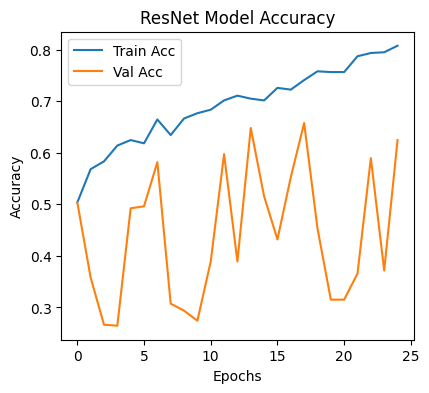

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

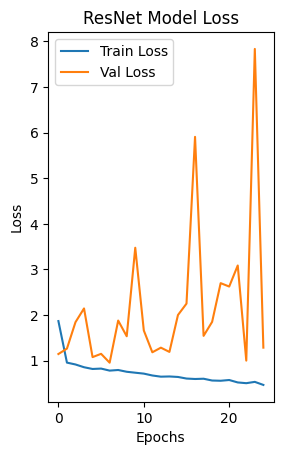

In [25]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ResNet Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Alternative ResNet Configuration

Using a simpler ResNet-inspired architecture with custom configuration.

In [26]:
def build_custom_resnet():
    """Build a custom ResNet-inspired model with skip connections."""
    inputs = layers.Input(shape=(128, 128, 1))
    
    # Convert grayscale to 3 channels
    x = layers.Conv2D(3, (1, 1), padding='same', name='rgb_conv')(inputs)
    
    # Initial Conv Block
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # ResNet Block 1
    shortcut1 = x
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut1])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 2
    shortcut2 = layers.Conv2D(128, (1, 1), strides=2, use_bias=False)(x)
    shortcut2 = layers.BatchNormalization()(shortcut2)
    x = layers.Conv2D(128, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut2])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 3
    shortcut3 = layers.Conv2D(256, (1, 1), strides=2, use_bias=False)(x)
    shortcut3 = layers.BatchNormalization()(shortcut3)
    x = layers.Conv2D(256, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut3])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 4
    shortcut4 = layers.Conv2D(512, (1, 1), strides=2, use_bias=False)(x)
    shortcut4 = layers.BatchNormalization()(shortcut4)
    x = layers.Conv2D(512, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut4])
    x = layers.Activation('relu')(x)
    
    # Global Average Pooling and Dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(1500, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='Custom_ResNet')
    return model

In [27]:
resnet = build_custom_resnet()
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
resnet.summary()

Model: "Custom_ResNet"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃   Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input_layer_4      │ (None, 128, 128, │         0 │ -                │
│ (InputLayer)       │ 1)               │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ rgb_conv (Conv2D)  │ (None, 128, 128, │         6 │ input_layer_4[0… │
│                    │ 3)               │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_23 (Conv2D) │ (None, 64, 64,   │     9,408 │ rgb_conv[0][0]   │
│                    │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ batch_normalizati… │ (None, 64, 64,   │       256 │ conv2d_23[0][0]  │
│ (BatchNormalizati… │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ activation_4       │ (None, 64, 64,   │         0 │ batch_normaliza… │
│ (Activation)       │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ max_pooling2d_4    │ (None, 32, 32,   │         0 │ activation_4[0]… │
│ (MaxPooling2D)     │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_24 (Conv2D) │ (None, 32, 32,   │    36,864 │ max_pooling2d_4… │
│                    │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ batch_normalizati… │ (None, 32, 32,   │       256 │ conv2d_24[0][0]  │
│ (BatchNormalizati… │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ activation_5       │ (None, 32, 32,   │         0 │ batch_normaliza… │
│ (Activation)       │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_25 (Conv2D) │ (None, 32, 32,   │    36,864 │ activation_5[0]… │
│                    │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ batch_normalizati… │ (None, 32, 32,   │       256 │ conv2d_25[0][0]  │
│ (BatchNormalizati… │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ add_4 (Add)        │ (None, 32, 32,   │         0 │ batch_normaliza… │
│                    │ 64)              │           │ max_pooling2d_4… │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ activation_6       │ (None, 32, 32,   │         0 │ add_4[0][0]      │
│ (Activation)       │ 64)              │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_27 (Conv2D) │ (None, 16, 16,   │    73,728 │ activation_6[0]… │
│                    │ 128)             │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ batch_normalizati… │ (None, 16, 16,   │       512 │ conv2d_27[0][0]  │
│ (BatchNormalizati… │ 128)             │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ activation_7       │ (None, 16, 16,   │         0 │ batch_normaliza… │
│ (Activation)       │ 128)             │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_28 (Conv2D) │ (None, 16, 16,   │   147,456 │ activation_7[0]… │
│                    │ 128)             │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ conv2d_26 (Conv2D) │ (None, 16, 16,   │     8,192 │ acti

 Total params: 5,685,561 (21.69 MB)

 Trainable params: 5,679,801 (21.67 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [29]:
training_history = resnet.fit(x=train_gen, validation_data=val_gen, epochs=25)

Epoch 1/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.5837 - loss: 0.9273 - val_accuracy: 0.2665 - val_loss: 1.5269
Epoch 2/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.6639 - loss: 0.7606 - val_accuracy: 0.2665 - val_loss: 1.4837
Epoch 3/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.7383 - loss: 0.6349 - val_accuracy: 0.5156 - val_loss: 2.1747
Epoch 4/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.8458 - loss: 0.4149 - val_accuracy: 0.3191 - val_loss: 3.2748
Epoch 5/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9027 - loss: 0.2440 - val_accuracy: 0.3385 - val_loss: 3.4527
Epoch 6/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 401s 3s/step - accuracy: 0.9188 - loss: 0.2001 - val_accuracy: 0.3735 - val_loss: 2.3060
Epoch 7/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 401s 3s/step - accuracy: 0.9348 - loss: 0.1673 - val_accuracy: 0.5058 - val_loss: 2.1598
Epoch 8/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - accuracy: 0.9436 - loss: 0.1478 - val_accu

In [30]:
val_loss, val_acc = resnet.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.3969 - loss: 5.2372

Validation Accuracy: 39.69%


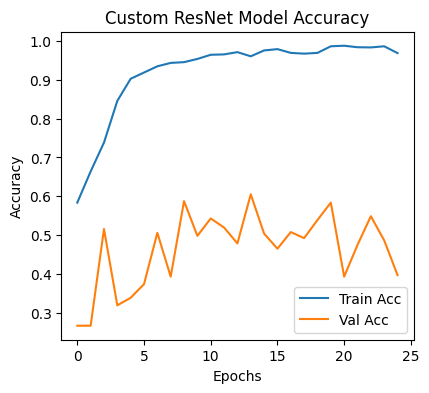

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(training_history.history['accuracy'], label='Train Acc')
plt.plot(training_history.history['val_accuracy'], label='Val Acc')
plt.title('Custom ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

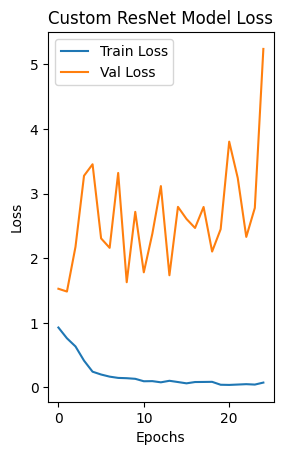

In [32]:
plt.subplot(1,2,2)
plt.plot(training_history.history['loss'], label='Train Loss')
plt.plot(training_history.history['val_loss'], label='Val Loss')
plt.title('Custom ResNet Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()